## 1. Introduction
### This project explores the key drivers of Perth house prices using a dataset of ~33,000 property records, each containing structural, location, and pricing information. The goal is to identify which features most strongly influence price and to visualise general market patterns.


In [1]:
#Importing required modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#Making large numbers be displayed in standard notation rather than scientific notation
pd.set_option('display.float_format', '{:,.2f}'.format)

## 2. Data Loading and Preview
### Reading data from .csv file to dataframe, and generating a preview of the data

In [3]:
df = pd.read_csv("all_perth_310121.csv")

In [4]:
df.head(15)

,ADDRESS,SUBURB,PRICE,BEDROOMS,BATHROOMS,GARAGE,LAND_AREA,FLOOR_AREA,BUILD_YEAR,CBD_DIST,NEAREST_STN,NEAREST_STN_DIST,DATE_SOLD,POSTCODE,LATITUDE,LONGITUDE,NEAREST_SCH,NEAREST_SCH_DIST,NEAREST_SCH_RANK
0,1 Acorn Place,South Lake,565000,4,2,2.00,600,160,"2,003.00",18300,Cockburn Central Station,1800,09-2018\r,6164,-32.12,115.84,LAKELAND SENIOR HIGH SCHOOL,0.83,NaN
1,1 Addis Way,Wandi,365000,3,2,2.00,351,139,"2,013.00",26900,Kwinana Station,4900,02-2019\r,6167,-32.19,115.86,ATWELL COLLEGE,5.52,129.00
2,1 Ainsley Court,Camillo,287000,3,1,1.00,719,86,"1,979.00",22600,Challis Station,1900,06-2015\r,6111,-32.12,115.99,KELMSCOTT SENIOR HIGH SCHOOL,1.65,113.00
3,1 Albert Street,Bellevue,255000,2,1,2.00,651,59,"1,953.00",17900,Midland Station,3600,07-2018\r,6056,-31.90,116.04,SWAN VIEW SENIOR HIGH SCHOOL,1.57,NaN
4,1 Aman Place,Lockridge,325000,4,1,2.00,466,131,"1,998.00",11200,Bassendean Station,2000,11-2016\r,6054,-31.89,115.95,KIARA COLLEGE,1.51,NaN
5,1 Amethyst Crescent,Mount Richon,409000,4,2,1.00,759,118,"1,991.00",27300,Armadale Station,1000,03-2013\r,6112,-32.15,116.02,ARMADALE SENIOR HIGH SCHOOL,1.23,NaN
6,1 Ardara Lane,Hilbert,400000,3,2,2.00,386,132,"2,014.00",28200,Armadale Station,3700,05-2016\r,6112,-32.18,115.99,DALE CHRISTIAN SCHOOL,2.49,NaN
7,1 Arnside Bend,Waikiki,370000,4,2,2.00,468,158,"2,013.00",41700,Warnbro Station,1100,03-2019\r,6169,-32.32,115.76,SOUTH COAST BAPTIST COLLEGE,0.49,NaN
8,1 Arrochar Court,Hamersley,565000,4,2,3.00,875,168,"1,983.00",12100,Warwick Station,2500,06-2020\r,6022,-31.85,115.82,WARWICK SENIOR HIGH SCHOOL,1.22,NaN
9,1 Arundel Street,Bayswater,685000,3,2,8.00,552,126,"1,999.00",5900,Bayswater Station,508,10-2019\r,6053,-31.92,115.91,CHISHOLM CATHOLIC COLLEGE,0.94,29.00


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33656 entries, 0 to 33655
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ADDRESS           33656 non-null  object 
 1   SUBURB            33656 non-null  object 
 2   PRICE             33656 non-null  int64  
 3   BEDROOMS          33656 non-null  int64  
 4   BATHROOMS         33656 non-null  int64  
 5   GARAGE            31178 non-null  float64
 6   LAND_AREA         33656 non-null  int64  
 7   FLOOR_AREA        33656 non-null  int64  
 8   BUILD_YEAR        30501 non-null  float64
 9   CBD_DIST          33656 non-null  int64  
 10  NEAREST_STN       33656 non-null  object 
 11  NEAREST_STN_DIST  33656 non-null  int64  
 12  DATE_SOLD         33656 non-null  object 
 13  POSTCODE          33656 non-null  int64  
 14  LATITUDE          33656 non-null  float64
 15  LONGITUDE         33656 non-null  float64
 16  NEAREST_SCH       33656 non-null  object

## 3. Exploratory Overview
### Summary statistics and plot of overall distribution of house prices in Perth

In [6]:
df.describe()

,PRICE,BEDROOMS,BATHROOMS,GARAGE,LAND_AREA,FLOOR_AREA,BUILD_YEAR,CBD_DIST,NEAREST_STN_DIST,POSTCODE,LATITUDE,LONGITUDE,NEAREST_SCH_DIST,NEAREST_SCH_RANK
count,"33,656.00","33,656.00","33,656.00","31,178.00","33,656.00","33,656.00","30,501.00","33,656.00","33,656.00","33,656.00","33,656.00","33,656.00","33,656.00","22,704.00"
mean,"637,072.01",3.66,1.82,2.20,"2,740.64",183.50,"1,989.71","19,777.37","4,523.37","6,089.42",-31.96,115.88,1.82,72.67
std,"355,825.63",0.75,0.59,1.37,"16,693.51",72.10,20.96,"11,364.42","4,495.06",62.17,0.18,0.12,1.75,40.64
min,"51,000.00",1.00,1.00,1.00,61.00,1.00,"1,868.00",681.00,46.00,"6,003.00",-32.47,115.58,0.07,1.00
25%,"410,000.00",3.00,1.00,2.00,503.00,130.00,"1,978.00","11,200.00","1,800.00","6,050.00",-32.07,115.79,0.88,39.00
50%,"535,500.00",4.00,2.00,2.00,682.00,172.00,"1,995.00","17,500.00","3,200.00","6,069.00",-31.93,115.85,1.35,68.00
75%,"760,000.00",4.00,2.00,2.00,838.00,222.25,"2,005.00","26,600.00","5,300.00","6,150.00",-31.84,115.97,2.10,105.00
max,"2,440,000.00",10.00,16.00,99.00,"999,999.00",870.00,"2,017.00","59,800.00","35,500.00","6,558.00",-31.46,116.34,23.25,139.00


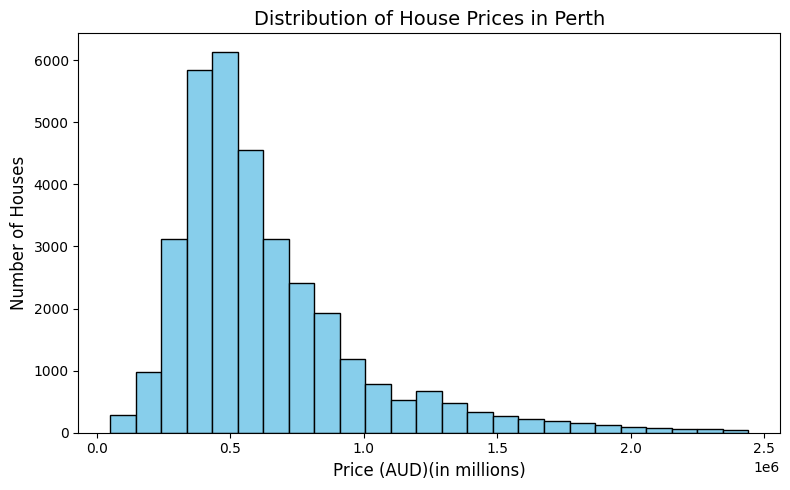

In [7]:
fig, ax = plt.subplots(figsize=(8,5))  
ax.hist(df['PRICE'], bins=25, color='skyblue', edgecolor='black')

ax.set_title('Distribution of House Prices in Perth', fontsize=14)
ax.set_xlabel('Price (AUD)(in millions)', fontsize=12)
ax.set_ylabel('Number of Houses', fontsize=12)

fig.tight_layout()  
plt.show()

fig.savefig("plots/overall_house_price_distribution.png", dpi=300)

Overall, distribution of house prices is skewed to the right, with the majority of prices between 300,000 and 700,000 AUD, with a few luxury properties extending out up to around 2,400,000 AUD.

## 4. Feature Relationships
#### Analysing and visualising the effect of different features of houses on their prices.

### a. Price vs. Land Area

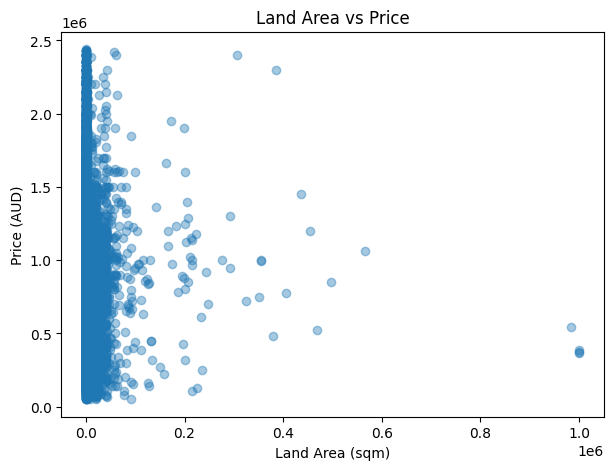

In [8]:
#Plotting a graph of land area against house price.
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df['LAND_AREA'], df['PRICE'], alpha=0.4)
ax.set_xlabel('Land Area (sqm)')
ax.set_ylabel('Price (AUD)')
ax.set_title('Land Area vs Price')
plt.show()

While we would normally expect Land Area and Price to have a rather strong positive correlation, the plot above does not reflect this prediction. Interestingly, we see that there are a few properties with incredible high values for land area, yet rather standard prices. I decided to look into these, and obtained the information of the top 5 properties with the greatest land area values below.

In [9]:
df.nlargest(5, 'LAND_AREA')[['ADDRESS', 'SUBURB', 'PRICE', 'FLOOR_AREA', 'LAND_AREA']]

,ADDRESS,SUBURB,PRICE,FLOOR_AREA,LAND_AREA
2684,11 Semerwater Crescent,Aveley,375000,175,999999
3575,12 Gailey Way,Aveley,385000,140,999999
27619,60 Semerwater Crescent,Aveley,365000,172,999999
16791,3 Longstaff Avenue,Alkimos,545000,216,983690
4261,1264 Chittering Road,Bullsbrook,1060000,182,566786


As we may have expected, values such as 1 million square metres for land area of a house are quite strange and probably not exactly what we think about when we ask about land area. Indeed, these properties' values for land area likely isn't just the area of the land in which the house is built itself, but likely includes some other land outside that is somehow associated with the property. This is further supported by the fact that these top four properties all do seem to be in locations at the edge of their suburbs, and right next to large plots of land. 

Due to the highly right-skewed distribution of land area, with a substantial number of very large semi-rural and acreage properties, land area was capped at the 90th percentile (≈ 2,300 sqm). This focuses the analysis on typical residential housing while excluding properties that follow fundamentally different pricing dynamics.

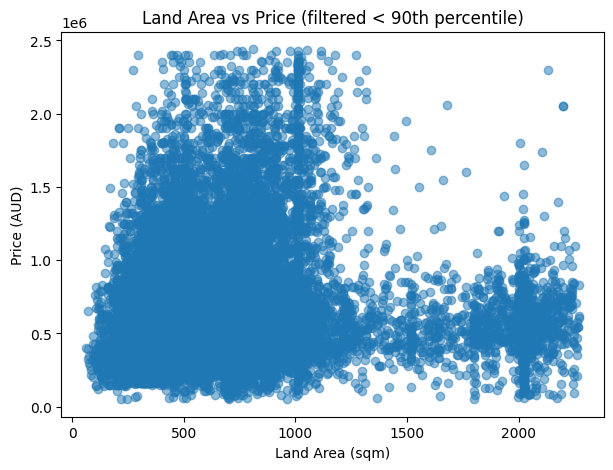

           PRICE  LAND_AREA
PRICE       1.00       0.06
LAND_AREA   0.06       1.00


In [10]:
cutoff = df["LAND_AREA"].quantile(0.90)
df_filt_land_area = df[df["LAND_AREA"] <= cutoff]
fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(df_filt_land_area['LAND_AREA'], df_filt_land_area['PRICE'], alpha=0.5)
ax.set_xlabel('Land Area (sqm)')
ax.set_ylabel('Price (AUD)')
ax.set_title('Land Area vs Price (filtered < 90th percentile)')
plt.show()

fig.savefig("plots/landarea_vs_price.png", dpi=300)

print(df_filt_land_area[['PRICE','LAND_AREA']].corr())

Even with the filtered dataset however, we do not see the kind of positive correlation we expect. This shows that when it comes to house prices, land area is surprisingly not a great determinant, and is likely less significant of a factor than others such as suburb, floor area, and other factors. We can see this as well from the correlation matrix, where land area and price only have a correlation r-value of 0.06, signifying almost no correlation, only very little positive correlation.

### b. Price vs. Building Area

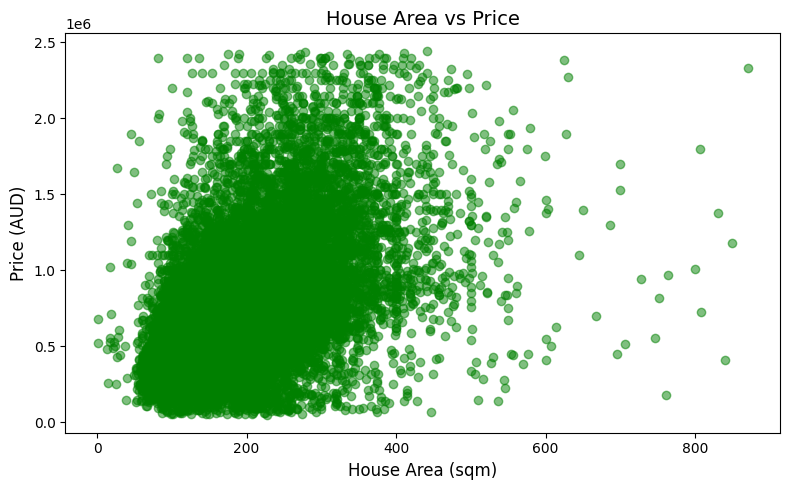

In [11]:
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(df['FLOOR_AREA'], df['PRICE'], alpha=0.5, color='green')
ax.set_title('House Area vs Price', fontsize=14)
ax.set_xlabel('House Area (sqm)', fontsize=12)
ax.set_ylabel('Price (AUD)', fontsize=12)

plt.tight_layout()
plt.show()

fig.savefig('plots/housearea_vs_price.png', dpi=300)

### c. Price by Number of Bedrooms

C:\Users\prana\AppData\Local\Temp\ipykernel_124544\514247271.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BEDROOMS', y='PRICE', data=df, ax=ax, palette='pastel')


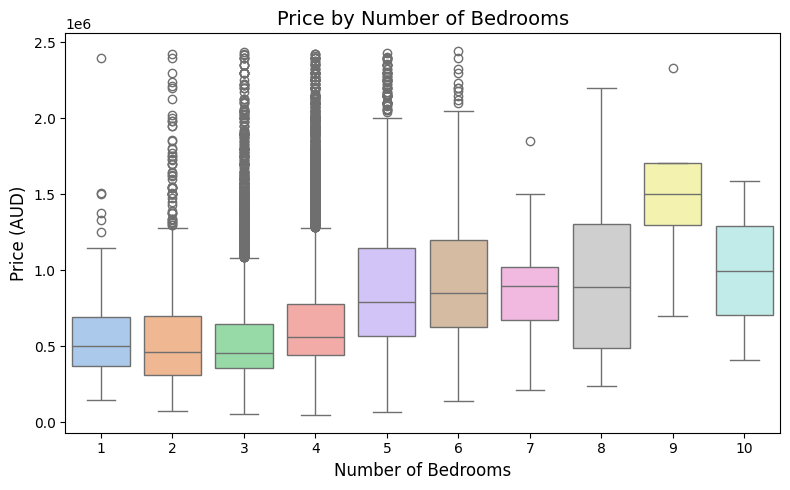

In [12]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(x='BEDROOMS', y='PRICE', data=df, ax=ax, palette='pastel')

ax.set_title('Price by Number of Bedrooms', fontsize=14)
ax.set_xlabel('Number of Bedrooms', fontsize=12)
ax.set_ylabel('Price (AUD)', fontsize=12)

plt.tight_layout()
plt.show()

fig.savefig('plots/price_by_bedrooms.png', dpi=300)

The boxplot and distribution of house prices for each value of number of bedrooms seems to overall increase as houses have more bedrooms. However, overall, the number of bedrooms value with the lowest distribution seems to be for 3 bedroom houses, followed by 2 bedroom houses and 1 bedroom houses, which are similar in price distribution. This is likely because people usually don't need 3 bedroom houses, so there's less demand. From 3-bedrooms onwards however, we see a rather steady increase in price distribution as number of bedrooms increases. 

### d. Price by Number of Bathrooms

C:\Users\prana\AppData\Local\Temp\ipykernel_124544\772066898.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='BATHROOMS', y='PRICE', data=df, ax=ax, palette='deep')


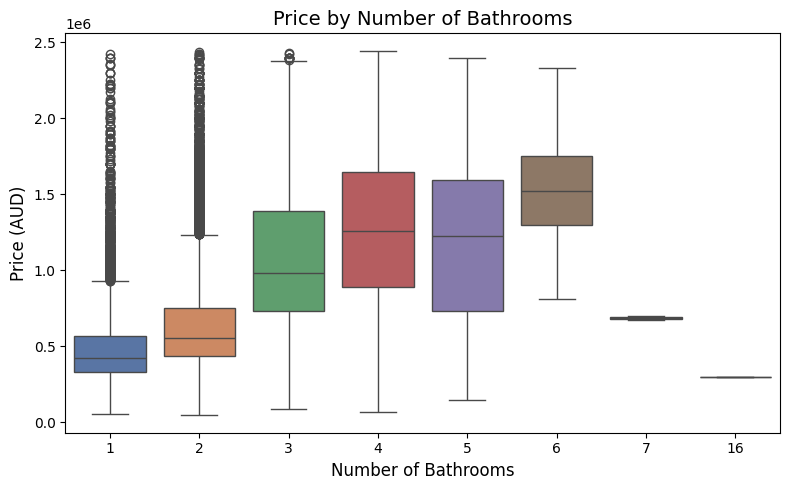

In [13]:
fig, ax = plt.subplots(figsize=(8,5))

sns.boxplot(x='BATHROOMS', y='PRICE', data=df, ax=ax, palette='deep')

ax.set_title('Price by Number of Bathrooms', fontsize=14)
ax.set_xlabel('Number of Bathrooms', fontsize=12)
ax.set_ylabel('Price (AUD)', fontsize=12)

plt.tight_layout()
plt.show()
fig.savefig('plots/price_by_bathrooms.png', dpi=300)

We see clearer increase in price distribution for houses as the number of bathrooms increase, than when we analysed based on number of bedrooms. This is likely because increasing the number of bedrooms might not always be a good thing - if other factors such as floor/land area and number of bathrooms are kept relatively the same, this would mean less space, and perhaps resources in terms of bathrooms and garages per bedroom, and therefore probably per person too. So in some cases, a greater number of bedrooms may not certainly lead to higher price - it could lead to a less desirable property, therefore ending up with a lower price. However, when we increase the number of bathrooms, due to their nature of being not too space consuming, and not necessarily meaning more people in the house, rather more bathrooms per bedroom, which is a good thing, this is likely why we see a more clear positive trend with prices when number of bathrooms increases - it's almost always a good thing.

### e. Price vs. Distance to CBD

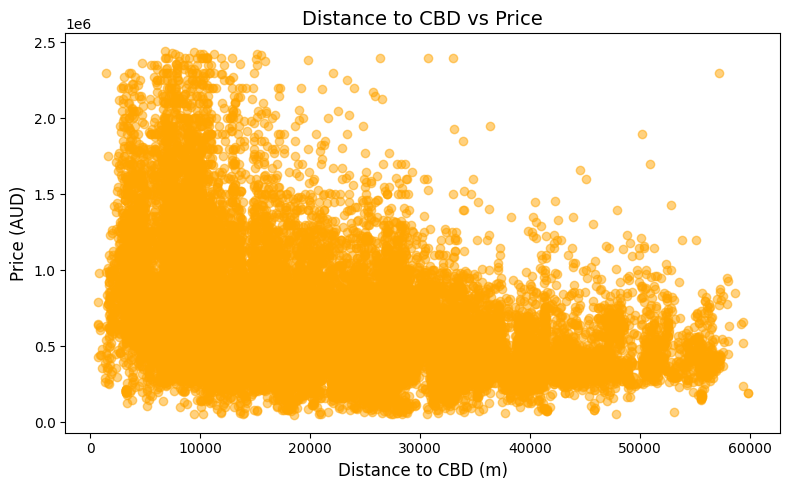

In [14]:
fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(df['CBD_DIST'], df['PRICE'], alpha=0.5, color='orange')
ax.set_title('Distance to CBD vs Price', fontsize=14)
ax.set_xlabel('Distance to CBD (m)', fontsize=12)
ax.set_ylabel('Price (AUD)', fontsize=12)

plt.tight_layout()
plt.show()

fig.savefig('plots/distancetocbd_vs_price.png', dpi=300)

Although not as linear of a downward relationship we might expect, there is still a rather negative correlation between price and distance to CBD, meaning houses closer to the CBD are usually more expensive. The bottom left triangle being so populated, while the top right triangle is mostly empty, is interesting. it means it's more common to see properties with lower distance to CBD and low price, than high distance to CBD and high price. This shows that there are many properties that are not far from the CBD but still have lower prices, whereas the opposite - properties far from the CBD with high prices - is not so common. 

### f. Price by Rank of Nearest School

C:\Users\prana\AppData\Local\Temp\ipykernel_124544\3257007616.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filt_school_rank['NEAREST_SCH_RANK'] = df_filt_school_rank['NEAREST_SCH_RANK'].astype(int) #to remove '.0' from x-axis points
C:\Users\prana\AppData\Local\Temp\ipykernel_124544\3257007616.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(mean_price_by_rank['NEAREST_SCH_RANK'], rotation=90)


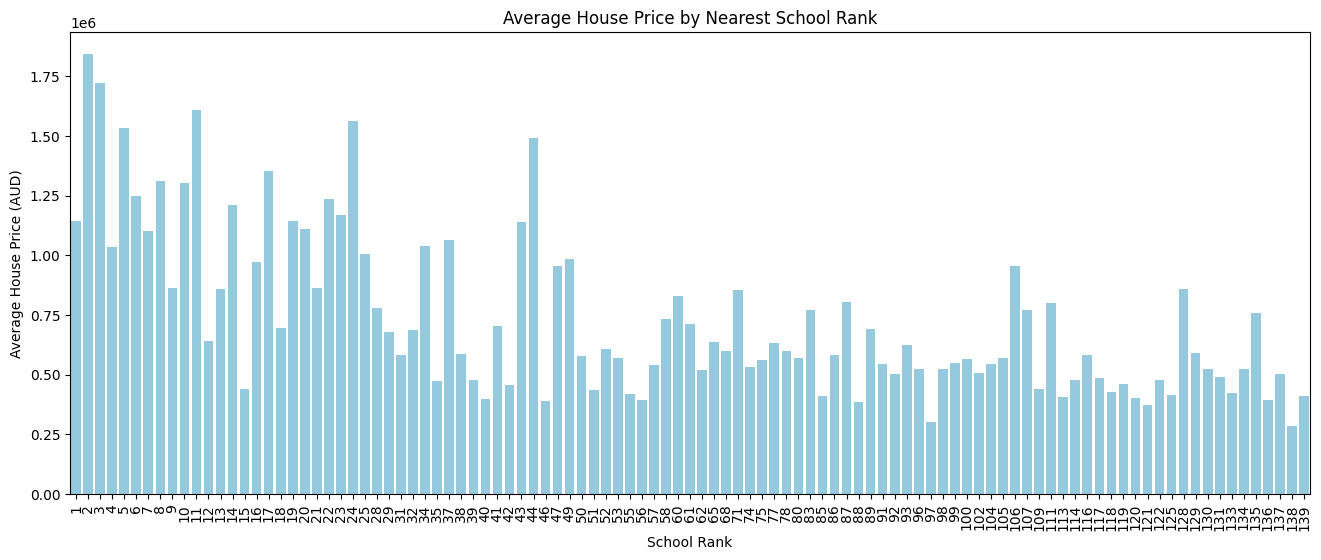

In [15]:
df_filt_school_rank = df.dropna(subset=['NEAREST_SCH_RANK'])
df_filt_school_rank['NEAREST_SCH_RANK'] = df_filt_school_rank['NEAREST_SCH_RANK'].astype(int) #to remove '.0' from x-axis points
mean_price_by_rank = df_filt_school_rank.groupby('NEAREST_SCH_RANK')['PRICE'].mean().reset_index()

fig, ax = plt.subplots(figsize=(16,6))
sns.barplot(x='NEAREST_SCH_RANK', y='PRICE', data=mean_price_by_rank, ax=ax, color='skyblue')

ax.set_xticklabels(mean_price_by_rank['NEAREST_SCH_RANK'], rotation=90)

ax.set_xlabel('School Rank')
ax.set_ylabel('Average House Price (AUD)')
ax.set_title('Average House Price by Nearest School Rank')
plt.show()

fig.savefig('plots/avg_price_by_rank_of_nearest_school_hist.png', dpi=300)

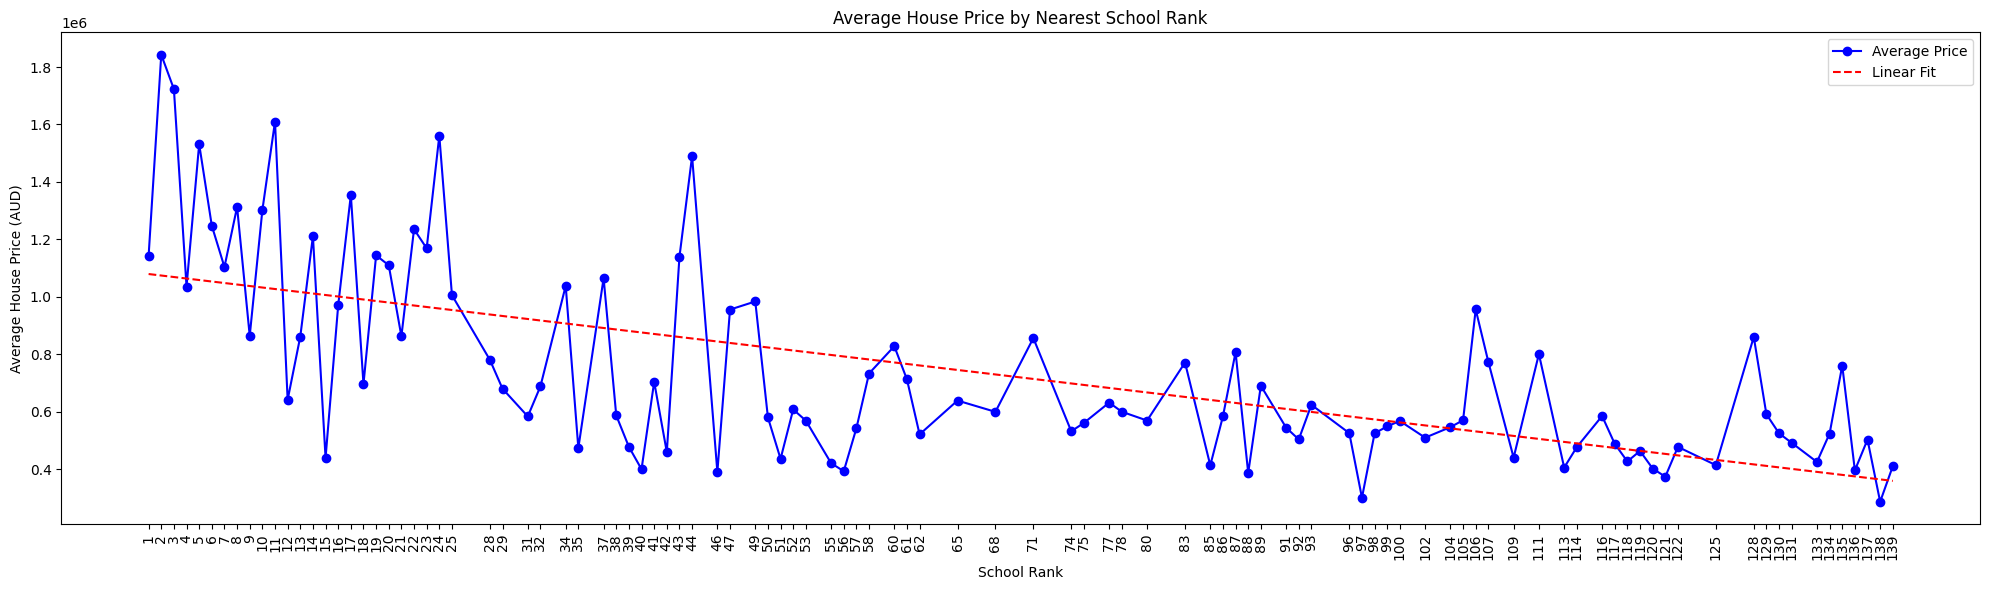

In [16]:
fig, ax = plt.subplots(figsize=(20,6))
ax.plot(mean_price_by_rank['NEAREST_SCH_RANK'], mean_price_by_rank['PRICE'], '-o', color='blue', label='Average Price')

x = mean_price_by_rank['NEAREST_SCH_RANK']
y = mean_price_by_rank['PRICE']
slope, intercept = np.polyfit(x, y, 1)
ax.plot(x, slope*x + intercept, color='red', linestyle='--', label='Linear Fit')

ax.set_xlabel('School Rank')
ax.set_ylabel('Average House Price (AUD)')
ax.set_title('Average House Price by Nearest School Rank')
ax.set_xticks(mean_price_by_rank['NEAREST_SCH_RANK'])
ax.set_xticklabels(mean_price_by_rank['NEAREST_SCH_RANK'], rotation=90)

ax.legend()
fig.tight_layout()
plt.show()

fig.savefig('plots/avg_price_by_rank_of_nearest_school_plot_with_lobf.png', dpi=300)

Overall, as the rank of the nearest school gets better, the price of the house increases.

### g. Correlation Matrix

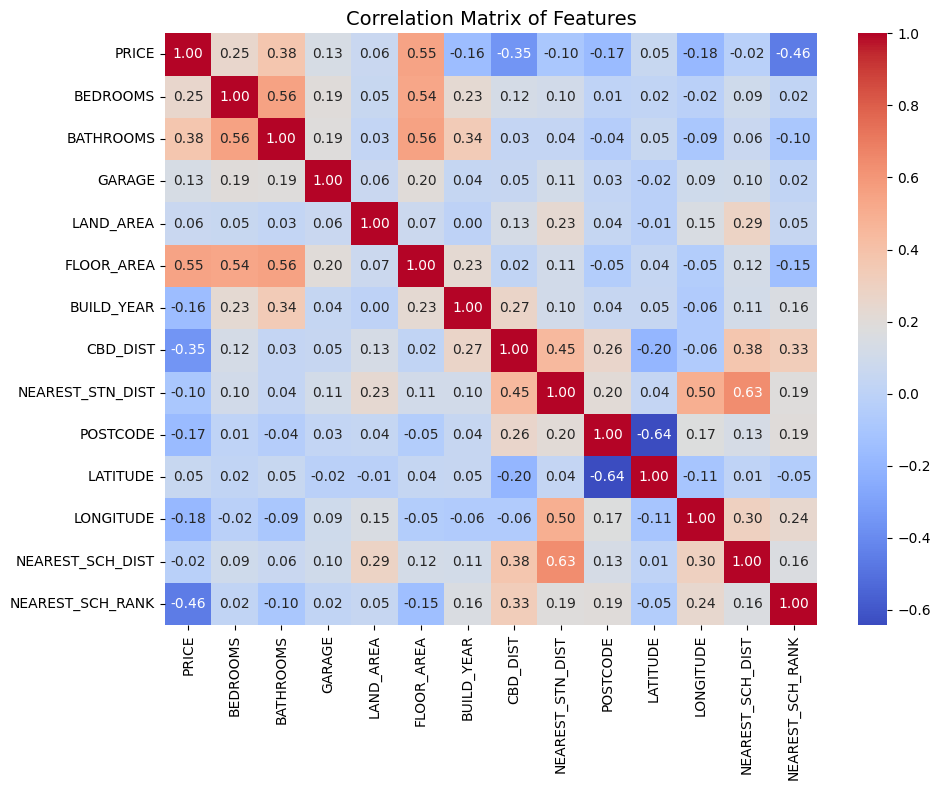

In [17]:
numeric_df = df.select_dtypes(include='number')

fig, ax = plt.subplots(figsize=(10,8))

corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=ax)

ax.set_title('Correlation Matrix of Features', fontsize=14)
plt.tight_layout()
plt.show()
#overall correlation matrix

fig.savefig("plots/overall_corr_matrix.png", dpi=300)

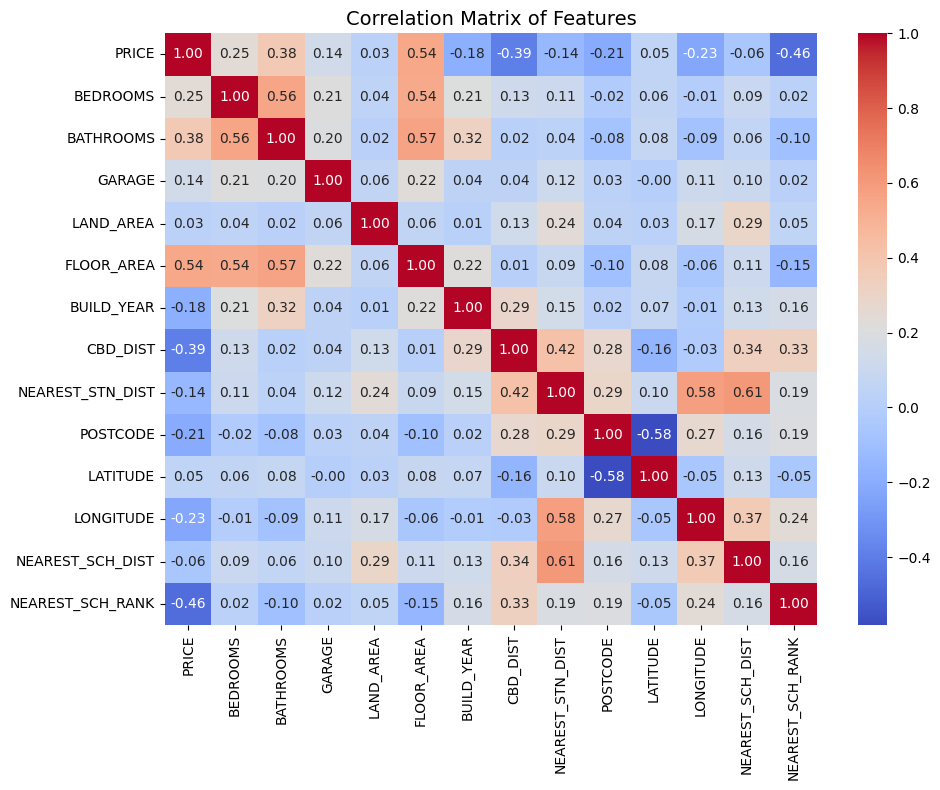

In [18]:
fig, ax = plt.subplots(figsize=(10,8))
numeric_df1 = numeric_df.dropna(subset=['NEAREST_SCH_RANK'])
corr = numeric_df1.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=ax)

ax.set_title('Correlation Matrix of Features', fontsize=14)
plt.tight_layout()
plt.show()
#filtered out houses with no rank for nearest school, to see more accurate correlation value when it comes to the nearest school rank factor

## 5. Summary of Key Findings
- Housing prices in Perth are positively skewed, with the houses within the 300,000 to 700,000 AUD range.
- Land area shows minimal correlation with price (r ≈ 0.04), likely due to suburb and quality effects.
- Building area has a moderate positive correlation (r ≈ 0.55).
- Housing prices increase with both increasing number of bedrooms, and increasing number of bathrooms, though the positive relationship is stronger with the latter.
- Proximity to CBD shows a mild negative correlation (r ≈ -0.30), consistent with price gradients.
- Rank of nearest school has a moderate negative correlation (r ≈ -0.46)


## 6. Multivariate Regression Analysis
So far, we’ve looked at how individual features (like land area, floor area, bedrooms) relate to house price. But houses are influenced by multiple factors at once. Multivariate regression allows us to model the combined effect of several features and see which ones are truly significant in predicting house prices.

It also gives us coefficients (how much price changes per unit change in a feature) and measures of fit like R² (how much of the price variation is explained by the features).

Note, this regression is intended for explanatory analysis rather than price prediction.

#### Step 1: Fitting a Linear Regression Model

In [19]:
import pandas as pd
import statsmodels.api as sm

df_filtered = df[df['LAND_AREA'] < 4000]

# Features we want to test
features = ['FLOOR_AREA', 'LAND_AREA', 'BEDROOMS', 'BATHROOMS', 'CBD_DIST']
X = df_filtered[features]
y = df_filtered['PRICE']

# Add a constant for the intercept
X_const = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X_const).fit()

# Show the summary
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  PRICE   R-squared:                       0.497
Model:                            OLS   Adj. R-squared:                  0.497
Method:                 Least Squares   F-statistic:                     6112.
Date:                Mon, 12 Jan 2026   Prob (F-statistic):               0.00
Time:                        17:31:33   Log-Likelihood:            -4.2831e+05
No. Observations:               30922   AIC:                         8.566e+05
Df Residuals:                   30916   BIC:                         8.567e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         3.4e+05   7715.929     44.058      0.0

Model Results Summary Interpretation:
- Here, we use sm.OLS to fit an Ordinary Least Squares regression, the standard linear regression.
- From the results summary, we can see:
  - R-squared = 0.497: Model explains 49.7% of the variation in price, which is quite good and reasonable for house price data. Many key factors such as renovation condition, land slope, school zones and street appeal are not in our dataset, so ~0.50 is expected.
  - Adj. R-squared = 0.497 \- Almost the same as R-squared, indicating our predictors are genuinely useful (no inflation due to too many variables).
  - Prob(F-statistic) is low, < 0.001: Model is statistically significant overall.
  - Coefficients table: (p < 0.001 for all coefficients, so all features are extremely statistically significant.)
    - FLOOR_AREA: +\\$2638 per sqm \- large strong effect.
    - LAND_AREA: +\\$32.9 per sqm \- much smaller effect than floor area, showing that while land matters, it doesn't matter as strongly as internal house size.
    - BEDROOMS: -\\$32760 per bedroom. Here, the value is negative because in multivariate models, we increase the number of bedrooms while holding all other dependent variables (house size, land size, bathrooms and distance to CBD) constant. In such a case, if the number of bedrooms is increased, it often can mean bedrooms are smaller, the house is more cramped with less open space, ultimately leading to a lower valuation.
    - BATHROOMS: +\\$82320 \- large positive impact.
    - CBD_DIST: -\\$12.65 per metre \- about \\\$12650 less per each square kilometre further from the CBD.
  - Condition number: 122000: Large, which warns about possible multicollinearity.

#### Step 2: Evaluating Model Fit

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

model_sklearn = LinearRegression()
model_sklearn.fit(X, y)
y_pred = model_sklearn.predict(X)

# R² and RMSE
r2 = model_sklearn.score(X, y)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R²: {r2:.3f}")
print(f"RMSE: ${rmse:,.2f}")


R²: 0.497
RMSE: $250,748.55


Once again, we get an R-squared value of 0.497, so 49.7% of the price variability is explained by the model. RMSE is the average prediction error in dollars, so we have an average prediction error of approximately $250000.

#### Step 3: Residual Analysis

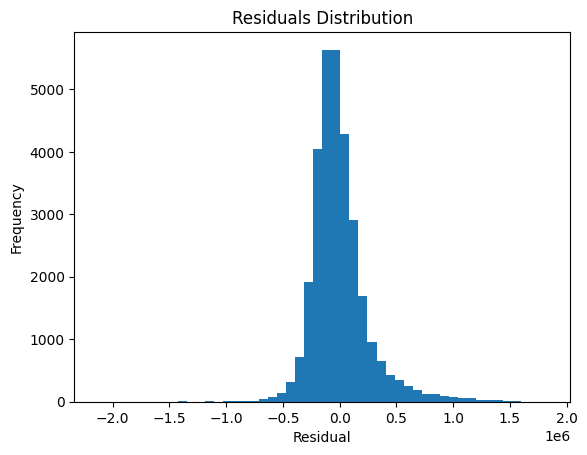

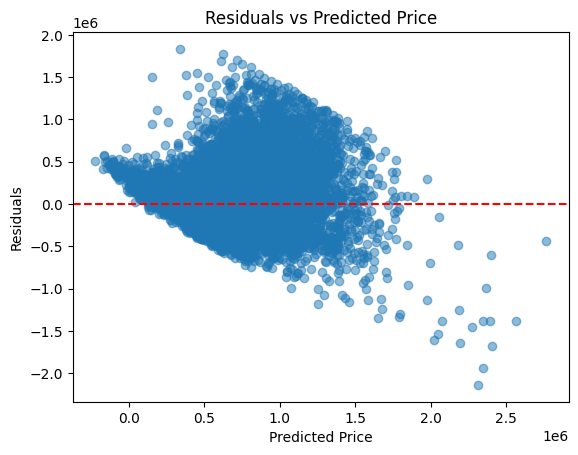

In [21]:
import matplotlib.pyplot as plt

residuals = y - y_pred

# Histogram of residuals
plt.hist(residuals, bins=50)
plt.title("Residuals Distribution")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.savefig("plots/residuals_distribution")
plt.show()


# Residuals vs Predicted
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Price")
plt.savefig("plots/residuals_vs_predicted_price")
plt.show()



The code above calculates residuals, which represent the model’s prediction error for each house:

Residual = Actual Price − Predicted Price

A residual of 0 means the prediction was perfect, positive values mean the model underpredicted, and negative values mean it overpredicted.

The first plot (the residual histogram) shows the overall distribution of these errors. In this case, the histogram is roughly centred around zero, but it is noticeably wide and slightly skewed. This suggests that while predictions tend to average out correctly, the model has a fairly large spread of errors — consistent with the high RMSE value.

The second plot (residuals vs predicted price) shows how the errors behave across different predicted price levels. Ideally, residuals should form a random cloud around the zero line. Instead, the pattern here fans outward and curves, with larger errors at higher predicted prices. This indicates heteroscedasticity (non-constant error variance) and nonlinearity, suggesting the model is missing important features and that a simple linear model is not capturing the full relationship between the predictors and price.

Overall, these plots show that the model is a useful starting point for learning, but improvements such as adding more features, applying transformations, or using more flexible models would likely reduce the systematic patterns in the residuals.

#### Step 4: Checking Feature Relationships / Multicollinearity

In [22]:
# Correlation matrix
print(X.corr())

# Variance Inflation Factor (VIF)
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)


            FLOOR_AREA  LAND_AREA  BEDROOMS  BATHROOMS  CBD_DIST
FLOOR_AREA        1.00       0.10      0.53       0.56     -0.03
LAND_AREA         0.10       1.00      0.05      -0.06      0.12
BEDROOMS          0.53       0.05      1.00       0.55      0.11
BATHROOMS         0.56      -0.06      0.55       1.00      0.02
CBD_DIST         -0.03       0.12      0.11       0.02      1.00
      Feature   VIF
0  FLOOR_AREA 12.88
1   LAND_AREA  3.30
2    BEDROOMS 24.18
3   BATHROOMS 18.15
4    CBD_DIST  3.89


Multicollinearity Check: Correlation Matrix + VIF

The correlation matrix shows how strongly each pair of features is linearly related. In our case, floor area, bedrooms, and bathrooms have moderate correlations with each other, while land area and CBD distance are mostly independent.

To detect deeper multicollinearity, we compute the Variance Inflation Factor (VIF) for each feature.
VIF measures how well a feature can be explained by the other predictors:

- VIF = 1 → no multicollinearity

- VIF > 5 → moderate multicollinearity

- VIF > 10 → strong multicollinearity

In our results, BEDROOMS, BATHROOMS, and FLOOR_AREA all have high VIF values (above 10), indicating that these variables overlap in the information they provide about house size. LAND_AREA and CBD_DIST have low VIF values, meaning they are relatively independent. This multicollinearity does not harm predictions, but it increases variance in coefficient estimates, reducing interpretability. We might remove or combine such features.

#### Step 5: Visualizing Predicted vs Actual Prices

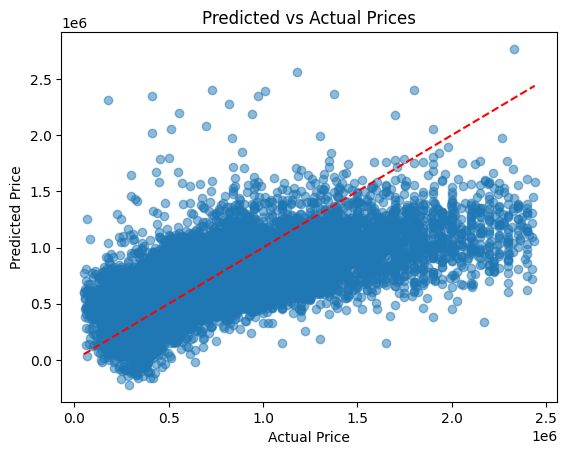

In [23]:
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Prices")
plt.savefig("plots/predicted_vs_actual_prices")
plt.show()

Interpreting the Predicted vs Actual Prices Plot

This scatter plot compares the model’s predicted house prices (y_pred) to the actual sale prices (y).
The red dashed line represents perfect predictions—points on this line would mean the model predicted the price exactly.

What the plot shows:

1. Reasonable performance at lower price ranges

  - For cheaper houses (e.g., below $600k), the predictions cluster more tightly around the red line—still spread out, but roughly centered.

  - This indicates the model captures general patterns for typical suburban homes.

2. Systematic underprediction for expensive houses

  - As actual prices increase, predicted prices consistently fall below the red line.

  - This means the model underestimates higher-priced properties.

  - Expensive homes often depend on factors not included in the model (e.g., suburb, prestige, views, build quality, location features, renovations).

3. High spread → limited predictive accuracy

  - The vertical spread around the line shows the prediction error.

  - Even at lower prices, predictions can be far off, reflecting the low R² (0.497) and high RMSE (~$250k).

4. Why linear regression behaves like this

  - Linear models tend to “pull extreme values toward the mean.”

  - Because luxury properties are rare (long right tail), and because the model lacks key explanatory features, it can’t capture the complexity needed to predict the top end accurately.

Overall interpretation:
The model does okay for typical, lower-priced homes but struggles significantly with higher-priced properties. This pattern suggests missing nonlinear relationships, missing categorical features (like suburb), and important omitted variables (garage size, year built, location features).

#### Key Takeaways — Multivariate Regression on Perth House Prices

- The model explains ≈50% of price variation (R² = 0.497), reasonable given omitted factors like suburb and renovations.

- FLOOR_AREA and BATHROOMS have the strongest positive effects on price.

- LAND_AREA has a smaller positive effect; CBD distance negatively affects price.

- BEDROOMS has a negative coefficient in the multivariate model, reflecting smaller, more compact layouts when other size features are held constant.

- Residual analysis shows larger errors for expensive properties and some heteroscedasticity, suggesting missing nonlinear or location-based factors.

- Multicollinearity exists among FLOOR_AREA, BEDROOMS, and BATHROOMS (VIFs > 10), but LAND_AREA and CBD_DIST are independent (VIF < 5).

- Next steps: include additional features, transform skewed variables, reduce multicollinearity, and explore flexible models like tree-based regressors for better predictions.